# Vietnam Statistical Arbitrage: PCA + OU Mean Reversion
## Baseline Notebook (Long-Only + VN30 Futures Hedge)

This notebook implements a statistical arbitrage strategy for Vietnam stocks:
- **Factor Model**: Rolling PCA on stock returns
- **Signal**: OU/AR(1) mean-reversion fitted to residuals
- **Portfolio**: Long-only, equal-weight, VN30-hedged
- **Goal**: Validate the research pipeline before optimization

Pipeline:
1. Data loading & preprocessing
2. Universe definition
3. Rolling PCA factor extraction
4. Residual construction
5. OU/AR(1) mean-reversion fitting
6. S-score signal generation
7. Long-only signal logic
8. Equal-weight portfolio construction
9. VN30 futures hedge computation
10. Backtest engine
11. Performance analysis & diagnostics

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')
print(f'Pandas: {pd.__version__}')
print(f'NumPy: {np.__version__}')

Libraries loaded successfully.
Pandas: 2.2.3
NumPy: 2.3.2


# SECTION 1: Data Loading and Preprocessing
## Vietnam stocks + VN30 futures prices, volumes, and returns

In [11]:
## Define date range
START_DATE = '2018-01-02'
END_DATE   = '2025-12-31'

print(f'Analysis period: {START_DATE} to {END_DATE}\n')

## Load Vietnam stock prices
stock_price_df = pd.read_csv('vietnam_stocks_price.csv', index_col=0, parse_dates=True)
print(f'Stock price shape: {stock_price_df.shape}')
print(f'Stock price date range: {stock_price_df.index.min().date()} to {stock_price_df.index.max().date()}')
print(f'Stock price missing (total): {stock_price_df.isna().sum().sum()}\n')

## Load Vietnam stock volumes
stock_volume_df = pd.read_csv('vietnam_stocks_volume.csv', index_col=0, parse_dates=True)
print(f'Stock volume shape: {stock_volume_df.shape}')
print(f'Stock volume date range: {stock_volume_df.index.min().date()} to {stock_volume_df.index.max().date()}\n')

## Load VN30 futures prices
fu_vn30_df = pd.read_csv('fu_vn30_price.csv', index_col=0, parse_dates=True)
print(f'VN30 futures shape: {fu_vn30_df.shape}')
print(f'VN30 futures date range: {fu_vn30_df.index.min().date()} to {fu_vn30_df.index.max().date()}\n')

Analysis period: 2018-01-02 to 2025-12-31

Stock price shape: (2872, 702)
Stock price date range: 2014-07-09 to 2025-12-31
Stock price missing (total): 248600

Stock volume shape: (2872, 702)
Stock volume date range: 2014-07-09 to 2025-12-31

VN30 futures shape: (2141, 5)
VN30 futures date range: 2017-08-10 to 2026-03-11



In [12]:
## Data cleaning: Remove stocks with >5% missing data
missing_pct = stock_price_df.isna().mean() * 100
stocks_to_keep = missing_pct[missing_pct <= 5].index
print(f'Removing {len(stock_price_df.columns) - len(stocks_to_keep)} stocks with >5% missing data')
print(f'Keeping {len(stocks_to_keep)} stocks\n')

stock_price_clean = stock_price_df[stocks_to_keep].copy()
stock_volume_clean = stock_volume_df[stocks_to_keep].copy()

## Forward-fill missing values (limit 2 days) to handle weekend/holiday gaps
stock_price_clean = stock_price_clean.ffill(limit=2)
stock_price_clean = stock_price_clean.dropna(axis=1, how='any')

stocks_final = stock_price_clean.columns
stock_volume_clean = stock_volume_clean[stocks_final].ffill(limit=5)

print(f'After cleaning: {len(stocks_final)} stocks')
print(f'Final stock price shape: {stock_price_clean.shape}')
print(f'Final stock price missing: {stock_price_clean.isna().sum().sum()}\n')

## Align VN30 futures (extract close price if multiple columns)
if isinstance(fu_vn30_df, pd.DataFrame):
    vn30_price_aligned = fu_vn30_df.iloc[:, 0].copy()  # Take first column (usually close price)
else:
    vn30_price_aligned = fu_vn30_df.copy()
vn30_price_aligned.name = 'VN30'

## Align to common trading calendar
common_dates = (vn30_price_aligned.index
                .intersection(stock_price_clean.index)
                .intersection(stock_volume_clean.index))
print(f'Common trading dates: {len(common_dates)} ({common_dates.min().date()} to {common_dates.max().date()})\n')

stock_price = stock_price_clean.loc[common_dates].copy()
stock_volume = stock_volume_clean.loc[common_dates].copy()
vn30_price = vn30_price_aligned.loc[common_dates].copy()

Removing 276 stocks with >5% missing data
Keeping 426 stocks

After cleaning: 279 stocks
Final stock price shape: (2872, 279)
Final stock price missing: 0

Common trading dates: 2098 (2017-08-10 to 2025-12-31)



In [13]:
## Compute daily returns
stock_returns = stock_price.pct_change().dropna()
vn30_returns = vn30_price.pct_change().dropna()

print(f'Stock returns shape: {stock_returns.shape}')
print(f'VN30 returns shape: {vn30_returns.shape}')
print(f'Stock returns date range: {stock_returns.index.min().date()} to {stock_returns.index.max().date()}')
print(f'VN30 returns date range: {vn30_returns.index.min().date()} to {vn30_returns.index.max().date()}\n')

## Summary statistics
print('Stock returns summary:')
print(f'  Mean: {stock_returns.mean().mean():.6f}')
print(f'  Std:  {stock_returns.std().mean():.6f}')
print(f'  Min:  {stock_returns.min().min():.6f}')
print(f'  Max:  {stock_returns.max().max():.6f}\n')

print('VN30 returns summary:')
print(f'  Mean: {vn30_returns.mean():.6f}')
print(f'  Std:  {vn30_returns.std():.6f}')
print(f'  Min:  {vn30_returns.min():.6f}')
print(f'  Max:  {vn30_returns.max():.6f}')

Stock returns shape: (2097, 279)
VN30 returns shape: (2097,)
Stock returns date range: 2017-08-11 to 2025-12-31
VN30 returns date range: 2017-08-11 to 2025-12-31

Stock returns summary:
  Mean: 0.000709
  Std:  0.026728
  Min:  -0.229842
  Max:  0.298436

VN30 returns summary:
  Mean: 0.000584
  Std:  0.015259
  Min:  -0.104337
  Max:  0.130302


# SECTION 2: Universe Definition
## Define trading universe based on liquidity filters
Universe logic: select top N stocks by average volume over a rolling window

In [14]:
def select_liquid_universe(price_df, volume_df, date, top_n=300, lookback_window=366):
    """
    Select top N stocks by liquidity on a given date.
    
    Args:
        price_df: DataFrame of stock prices
        volume_df: DataFrame of stock volumes
        date: Trading date
        top_n: Number of top liquid stocks to select
        lookback_window: Days to look back for liquidity calculation
        
    Returns:
        price_window: Clean price data for selected stocks
        volume_window: Clean volume data for selected stocks
    """
    # Filter stocks with price data available on the given date
    stocks_available = price_df.loc[date].notna()
    
    # Get lookback window
    window_start = date - pd.Timedelta(days=lookback_window)
    price_window = price_df.loc[window_start:date, stocks_available].copy()
    volume_window = volume_df.loc[window_start:date, stocks_available].copy()
    
    # Calculate average volume (most recent day)
    latest_volume = volume_window.iloc[-1]  # Most recent volume
    top_stocks = latest_volume.nlargest(top_n).index.tolist()
    
    # Clean: forward-fill, drop rows with any missing in final selection
    price_window = price_window[top_stocks].ffill(limit=2)
    price_window = price_window.dropna(axis=1, how='any')
    
    final_stocks = price_window.columns
    volume_window = volume_window[final_stocks].ffill(limit=5)
    
    return price_window, volume_window

## Test universe selection on a recent date
test_date = stock_price.index[-100]  # 100 days before end
test_price, test_volume = select_liquid_universe(stock_price, stock_volume, test_date, top_n=100)
print(f'Universe selection test (date={test_date.date()}):')
print(f'  Selected {len(test_price.columns)} liquid stocks')
print(f'  Price data shape: {test_price.shape}')
print(f'  Volume data shape: {test_volume.shape}')

Universe selection test (date=2025-08-12):
  Selected 100 liquid stocks
  Price data shape: (250, 100)
  Volume data shape: (250, 100)


# SECTION 3: Rolling PCA Factor Extraction
## Compute PCA factors on rolling estimation window
Strategy: standardize returns, compute empirical correlation, perform eigendecomposition

In [15]:
def standardize_returns(ret_window):
    """
    Standardize returns: Y_ik = (R_ik - mean_i) / std_i per stock
    """
    mean_per_stock = ret_window.mean(axis=0)
    std_per_stock = ret_window.std(axis=0, ddof=1).replace(0, np.nan)
    Y = (ret_window - mean_per_stock) / std_per_stock
    return Y.dropna(axis=1)  # drop any stock with zero std

def compute_correlation_matrix(Y):
    """
    Compute empirical correlation from standardized returns
    """
    M = Y.shape[0]  # number of observations
    return (Y.values.T @ Y.values) / (M - 1)

def eigen_decomposition_sorted(corr_matrix):
    """
    Eigendecomposition with eigenvalues sorted descending
    """
    eigvals, eigvecs = np.linalg.eigh(corr_matrix)
    idx = np.argsort(eigvals)[::-1]
    return eigvals[idx], eigvecs[:, idx]

def rolling_pca(returns, estimation_window=252, n_factors=15):
    """
    Rolling PCA on stock returns.
    
    Args:
        returns: DataFrame of stock returns (T x N)
        estimation_window: Window size for PCA estimation (days)
        n_factors: Number of factors to extract
        
    Returns:
        Dictionary mapping trading_date -> {
            'Q': factor loadings (N x n_factors)
            'stocks': stock tickers used
            'k': actual number of factors extracted
        }
    """
    dates = returns.index
    pca_dict = {}
    
    for t in range(estimation_window, len(dates)):
        trading_date = dates[t]
        
        # Estimation window: [t - window + 1, t-1] (EXCLUDE trading date t)
        est_start = t - estimation_window
        est_end = t  # non-inclusive in Python slicing
        ret_window = returns.iloc[est_start:est_end].copy()
        
        # Remove stocks with insufficient data in window
        ret_window = ret_window.dropna(axis=1, how='any')
        if ret_window.shape[1] < 2:
            continue
        
        # Standardize
        Y = standardize_returns(ret_window)
        if Y.shape[1] < 2:
            continue
        
        stocks = Y.columns
        
        # PCA
        corr = compute_correlation_matrix(Y)
        eigvals, eigvecs = eigen_decomposition_sorted(corr)
        
        # Number of factors
        k = min(n_factors, Y.shape[1] - 1)
        V = eigvecs[:, :k]  # eigenvectors (N x k)
        
        # Eigenportfolio weights: Q_i^j = v_i^j / sigma_i
        # (normalize by standard deviation per stock)
        std_i = ret_window[stocks].std(ddof=1).values  # (N,)
        std_i[std_i == 0] = np.nan
        Q = V / std_i.reshape(-1, 1)  # (N x k)
        
        pca_dict[trading_date] = {
            'Q': Q,
            'stocks': stocks,
            'k': k,
        }
    
    return pca_dict

## Run rolling PCA
print('Running rolling PCA...')
pca_results = rolling_pca(stock_returns, estimation_window=252, n_factors=15)
print(f'PCA computed for {len(pca_results)} trading dates')
print(f'Date range: {min(pca_results.keys()).date()} to {max(pca_results.keys()).date()}')

Running rolling PCA...
PCA computed for 1845 trading dates
Date range: 2018-08-14 to 2025-12-31


# SECTION 4: Residual Construction
## Use PCA factors to compute fitted & residual returns

In [18]:
def compute_residuals(returns, pca_dict, regression_window=60):
    """
    For each trading date with PCA factors:
    1. Regress stock returns on PCA factors using [t-window, t-1] data
    2. Compute fitted returns at t using estimated betas
    3. Residual = actual return - fitted return
    
    Args:
        returns: DataFrame of stock returns
        pca_dict: PCA results from rolling_pca()
        regression_window: Window for factor regression
        
    Returns:
        DataFrame of residuals aligned with pca_dict dates
    """
    dates = returns.index
    residuals = pd.DataFrame(index=dates, columns=returns.columns, dtype=float)
    
    for trading_date in sorted(pca_dict.keys()):
        if trading_date not in dates:
            continue
        
        t = dates.get_loc(trading_date)
        if t < regression_window:
            continue
        
        pca_info = pca_dict[trading_date]
        Q = pca_info['Q']  # (N x k)
        stocks = pca_info['stocks']
        
        # Regression window: [t - window, t - 1] (EXCLUDE trading date t)
        # This gives exactly window rows of historical data for regression
        reg_start = t - regression_window
        reg_end = t  # non-inclusive in Python slicing
        R_reg = returns.iloc[reg_start:reg_end, :][stocks].fillna(0).values  # (window x N)
        
        # Factor returns in regression window
        F_reg = R_reg @ Q  # (window x k)
        
        # OLS regression: R = alpha + beta @ F
        X = np.column_stack([np.ones(regression_window), F_reg])  # (window x (k+1))
        
        # Factor returns on trading date
        r_today = returns.loc[trading_date, stocks].fillna(0).values  # (N,)
        f_today = r_today @ Q  # (k,)
        x_today = np.concatenate([[1.0], f_today])  # (k+1,)
        
        # Estimate betas using pseudo-inverse for robustness
        try:
            beta_all = np.linalg.lstsq(X, R_reg, rcond=None)[0]  # ((k+1) x N)
        except:
            continue
        
        # Fitted return for each stock
        fitted_ret = x_today @ beta_all  # (N,)
        
        # Residual = actual - fitted
        for i, stock in enumerate(stocks):
            actual = returns.loc[trading_date, stock]
            if not np.isnan(actual):
                residuals.loc[trading_date, stock] = actual - fitted_ret[i]
    
    return residuals

## Compute residuals
print('Computing residuals...')
residuals = compute_residuals(stock_returns, pca_results, regression_window=60)
print(f'Residuals shape: {residuals.shape}')
print(f'Residuals missing: {residuals.isna().sum().sum()}')
print(f'Residuals date range: {residuals.index.min().date()} to {residuals.index.max().date()}')

Computing residuals...
Residuals shape: (2097, 279)
Residuals missing: 70308
Residuals date range: 2017-08-11 to 2025-12-31


# SECTION 5: OU/AR(1) Mean Reversion Fitting
## Fit Ornstein-Uhlenbeck model to residuals to estimate mean-reversion parameters

In [19]:
def fit_ou_model(residuals, window=60, limit=False, kappa_min=8.4):
    """
    Fit AR(1) / OU model to residuals.
    
    Cumulative sum: X_k = sum of epsilon_1:k
    AR(1) regression: X_t = a + b * X_{t-1} + zeta_t
    
    Mean reversion speed: kappa = -ln(b) * 252 (annualized)
    Long-run mean: mu = a / (1 - b)
    Equilibrium volatility: sigma_eq = sqrt(var(zeta) / (1 - b^2))
    
    Args:
        residuals: DataFrame of residuals
        window: Estimation window (days)
        limit: If True, filter by kappa >= kappa_min; if False, keep all valid
        kappa_min: Minimum kappa threshold (annualized)
        
    Returns:
        (kappa_df, mu_df, sigma_eq_df): DataFrames with OU parameters
    """
    kappa = pd.DataFrame(index=residuals.index, columns=residuals.columns, dtype=float)
    mu = kappa.copy()
    sigma_eq = kappa.copy()
    
    for t in range(window, len(residuals)):
        trading_date = residuals.index[t]
        
        # Regression window [t - window + 1, t]
        eps_window = residuals.iloc[t - window + 1:t + 1].copy()
        
        for stock in residuals.columns:
            eps = eps_window[stock].dropna().values
            
            if len(eps) < window:
                continue
            
            # Cumulative sum
            X = np.cumsum(eps)
            X_lag = X[:-1]
            X_now = X[1:]
            
            if len(X_lag) < 2:
                continue
            
            # OLS: X_t = a + b * X_{t-1} + zeta
            X_lag_mean = X_lag.mean()
            X_now_mean = X_now.mean()
            
            num = np.sum((X_lag - X_lag_mean) * (X_now - X_now_mean))
            denom = np.sum((X_lag - X_lag_mean) ** 2)
            
            if denom <= 1e-12:
                continue
            
            b = num / denom
            
            # Mean reversion constraint: 0 < b < 1
            if b <= 0 or b >= 1:
                continue
            
            # Annualized kappa
            k_daily = -np.log(b)
            k_annual = k_daily * 252
            
            # Optional filter
            if limit and k_annual < kappa_min:
                continue
            
            # Mean and sigma_eq
            a = X_now_mean - b * X_lag_mean
            m = a / (1 - b)
            
            zeta = X_now - (a + b * X_lag)
            var_zeta = np.var(zeta, ddof=1)
            
            if var_zeta <= 1e-12:
                continue
            
            sigma_eq_val = np.sqrt(var_zeta / (1 - b ** 2))
            
            # Store
            kappa.loc[trading_date, stock] = k_annual
            mu.loc[trading_date, stock] = m
            sigma_eq.loc[trading_date, stock] = sigma_eq_val
        
        # Cross-sectional mean-centering of mu (standardization)
        valid_mu = mu.loc[trading_date].notna()
        if valid_mu.any():
            mu.loc[trading_date, valid_mu] -= mu.loc[trading_date, valid_mu].mean()
    
    return kappa, mu, sigma_eq

## Fit OU model (without kappa filter first)
print('Fitting OU model to residuals (limit=False)...')
kappa_df, mu_df, sigma_eq_df = fit_ou_model(residuals=residuals, window=60, limit=False, kappa_min=8.4)
print(f'OU parameters created')
print(f'Kappa median: {kappa_df.stack().median():.2f} (annualized)')
print(f'Sigma_eq median: {sigma_eq_df.stack().median():.6f}')

Fitting OU model to residuals (limit=False)...
OU parameters created
Kappa median: 26.50 (annualized)
Sigma_eq median: 0.047331


# SECTION 6: S-Score Signal Generation
## Compute standardized signal from residuals and OU parameters

In [20]:
def compute_sscore(residuals, mu_df, sigma_eq_df, window=60):
    """
    S-score = (X_t - mu) / sigma_eq
    
    Where X_t = cumsum of residuals in the window [t - window + 1, t]
    
    S-score measures deviation from mean-reversion equilibrium in units of volatility.
    
    Args:
        residuals: DataFrame of residuals
        mu_df: DataFrame of long-run means
        sigma_eq_df: DataFrame of equilibrium volatilities
        window: Window for cumulative sum
        
    Returns:
        DataFrame of s-scores with same index/columns as residuals
    """
    sscore = pd.DataFrame(index=residuals.index, columns=residuals.columns, dtype=float)
    
    for t in range(window, len(residuals)):
        trading_date = residuals.index[t]
        
        # Cumulative residuals in window [t - window + 1, t]
        eps_window = residuals.iloc[t - window + 1:t + 1]
        X_t = eps_window.sum()  # cumsum, take last value
        
        mu = mu_df.loc[trading_date]
        sigma = sigma_eq_df.loc[trading_date]
        
        # Valid mask: all parameters must be non-null
        valid = mu.notna() & sigma.notna() & X_t.notna() & (sigma > 1e-12)
        
        sscore.loc[trading_date, valid] = (X_t[valid] - mu[valid]) / sigma[valid]
    
    return sscore

## Compute s-scores
print('Computing s-scores...')
sscore_df = compute_sscore(residuals, mu_df, sigma_eq_df, window=60)
print(f'S-score shape: {sscore_df.shape}')
print(f'S-score median: {sscore_df.stack().median():.4f}')
print(f'S-score std: {sscore_df.stack().std():.4f}')

Computing s-scores...
S-score shape: (2097, 279)
S-score median: -0.1883
S-score std: 179.4320


# SECTION 7: Long-Only Signal Logic
## Generate long-only trading signals based on s-score thresholds

Trading rules (long-only baseline):
- Open long: when s-score falls below -threshold (stock oversold/undervalued)
- Close long: when s-score rises above -close_threshold (mean-reversion towards equilibrium)

In [21]:
def generate_longonly_signals(sscore_df, s_open=1.25, s_close=0.50):
    """
    Long-only signal generation.
    
    Signal interpretation (based on s-score paper):
    - s-score < -s_open: stock is undervalued (oversold), OPEN LONG
    - s-score > -s_close: stock has mean-reverted back, CLOSE LONG
    
    Args:
        sscore_df: DataFrame of s-scores
        s_open: Threshold for opening long position (absolute value)
        s_close: Threshold for closing long position (absolute value)
        
    Returns:
        signals: DataFrame with {0: flat, 1: long} per stock per date
        current_positions: Series with most recent position state
    """
    signals = pd.DataFrame(0, index=sscore_df.index, columns=sscore_df.columns, dtype=int)
    positions = pd.Series(0, index=sscore_df.columns, dtype=int)
    
    for t in range(1, len(sscore_df)):
        s_prev = sscore_df.iloc[t - 1]
        new_positions = positions.copy()
        
        for stock in sscore_df.columns:
            val = s_prev[stock]
            if pd.isna(val):
                continue
            
            if positions[stock] == 0:  # Currently flat
                if val < -s_open:  # Very negative = undersold, open long
                    new_positions[stock] = 1
            
            elif positions[stock] == 1:  # Currently long
                if val > -s_close:  # Less negative = mean-reverted, close long
                    new_positions[stock] = 0
        
        signals.iloc[t] = new_positions
        positions = new_positions
    
    return signals

## Generate signals
print('Generating long-only signals...')
signals_df = generate_longonly_signals(sscore_df, s_open=1.25, s_close=0.50)
print(f'Signals shape: {signals_df.shape}')
total_long_signal_days = (signals_df == 1).sum().sum()
print(f'Total long signal-days: {total_long_signal_days}')
print(f'Avg positions per day: {(signals_df == 1).sum().mean():.2f}')

Generating long-only signals...
Signals shape: (2097, 279)
Total long signal-days: 144870
Avg positions per day: 519.25


# SECTION 8: Equal-Weight Portfolio Construction
## Build equal-weight long-only portfolio from signals

Portfolio rules:
- Equal weight across all active long positions on each date
- No leverage, no optimization
- Simple and transparent construction

In [22]:
def construct_portfolio(signals_df, max_positions=None):
    """
    Construct equal-weight portfolio from signals.
    
    On each date:
    - Count active long positions (signal = 1)
    - Assign equal weight 1/N to each long position
    - Other positions get weight 0
    
    Args:
        signals_df: DataFrame of long/flat signals
        max_positions: Optional cap on number of positions (None = no cap)
        
    Returns:
        weights: DataFrame with portfolio weights (sum to 1.0 on long positions)
    """
    weights = pd.DataFrame(0.0, index=signals_df.index, columns=signals_df.columns)
    
    for date in signals_df.index:
        signal_today = signals_df.loc[date]
        
        # Active longs
        long_stocks = signal_today[signal_today == 1].index.tolist()
        
        # Apply max_positions cap if specified
        if max_positions is not None and len(long_stocks) > max_positions:
            long_stocks = long_stocks[:max_positions]
        
        # Equal weight
        if len(long_stocks) > 0:
            weight_per_stock = 1.0 / len(long_stocks)
            weights.loc[date, long_stocks] = weight_per_stock
    
    return weights

## Construct portfolio
print('Constructing equal-weight portfolio...')
weights_df = construct_portfolio(signals_df, max_positions=None)
print(f'Weights shape: {weights_df.shape}')
print(f'Avg weight per date: {weights_df.sum(axis=1).mean():.4f}')  # Should be ~1.0 on long days
print(f'Sample weights sum (first 5 long days):')
long_days = weights_df[weights_df.sum(axis=1) > 0].head(5)
print(long_days.sum(axis=1))

Constructing equal-weight portfolio...
Weights shape: (2097, 279)
Avg weight per date: 0.8512
Sample weights sum (first 5 long days):
2018-11-07    1.0
2018-11-08    1.0
2018-11-09    1.0
2018-11-12    1.0
2018-11-13    1.0
dtype: float64


# SECTION 9: VN30 Futures Hedge Computation
## Compute rolling beta and hedge VN30 systematic risk with short futures

In [23]:
def compute_rolling_beta(stock_portfolio_returns, vn30_returns, beta_window=60):
    """
    Compute rolling beta of stock portfolio vs VN30.
    
    Beta_t = cov(R_portfolio_t, R_vn30_t) / var(R_vn30_t)
    
    Args:
        stock_portfolio_returns: Series of weighted stock returns
        vn30_returns: Series of VN30 returns
        beta_window: Window for rolling regression
        
    Returns:
        beta_series: Series of daily betas
    """
    # Align indices
    common_idx = stock_portfolio_returns.index.intersection(vn30_returns.index)
    R_stock = stock_portfolio_returns.loc[common_idx].fillna(0)
    R_vn30 = vn30_returns.loc[common_idx].fillna(0)
    
    beta_series = pd.Series(0.0, index=common_idx)
    
    for t in range(beta_window, len(common_idx)):
        date = common_idx[t]
        
        # Rolling window [t - beta_window + 1, t]
        stock_window = R_stock.iloc[t - beta_window + 1:t + 1].values
        vn30_window = R_vn30.iloc[t - beta_window + 1:t + 1].values
        
        cov = np.cov(stock_window, vn30_window)[0, 1]
        var_vn30 = np.var(vn30_window, ddof=1)
        
        if var_vn30 > 1e-12:
            beta = cov / var_vn30
            beta_series.loc[date] = beta
        else:
            beta_series.loc[date] = 0.0  # No variance, no beta
    
    return beta_series

## Compute portfolio returns and beta
print('Computing rolling beta for hedge sizing...')

# Portfolio stock returns (when long)
portfolio_returns = (weights_df * stock_returns).sum(axis=1)

# Rolling beta
beta_series = compute_rolling_beta(portfolio_returns, vn30_returns, beta_window=60)

print(f'Portfolio returns shape: {portfolio_returns.shape}')
print(f'Beta series shape: {beta_series.shape}')
print(f'Mean beta: {beta_series.mean():.4f}')
print(f'Median beta: {beta_series.median():.4f}')
print(f'Std beta: {beta_series.std():.4f}')

Computing rolling beta for hedge sizing...
Portfolio returns shape: (2097,)
Beta series shape: (2097,)
Mean beta: 0.1055
Median beta: 0.0766
Std beta: 0.1463


# SECTION 10: Backtest Engine
## Single clean backtest for PCA + long-only portfolio + VN30 hedge

In [24]:
def backtest_strategy(weights_df, stock_returns, vn30_returns, beta_series, 
                      initial_equity=100, slippage=0.0005):
    """
    Backtest long-only stock portfolio + VN30 futures hedge.
    
    Daily equity update:
    - Stock leg: position weights * stock returns
    - Hedge leg: -beta * vn30 returns (short futures)
    - Slippage: on position changes
    
    Args:
        weights_df: Portfolio weights
        stock_returns: Stock returns
        vn30_returns: VN30 futures returns
        beta_series: Rolling beta
        initial_equity: Starting equity
        slippage: Transaction cost factor
        
    Returns:
        equity_curve: Series of daily equity values
    """
    # Align data
    common_idx = (weights_df.index
                  .intersection(stock_returns.index)
                  .intersection(vn30_returns.index)
                  .intersection(beta_series.index))
    
    w = weights_df.loc[common_idx].fillna(0)
    r_stock = stock_returns.loc[common_idx].fillna(0)
    r_vn30 = vn30_returns.loc[common_idx].fillna(0)
    beta = beta_series.loc[common_idx].fillna(0)
    
    # Initialize equity curve
    equity = pd.Series(initial_equity, index=common_idx)
    
    for t in range(1, len(common_idx)):
        date_t = common_idx[t]
        date_prev = common_idx[t - 1]
        
        E_prev = equity.iloc[t - 1]
        
        # Current equity and positions
        w_today = w.loc[date_t]
        beta_today = beta.loc[date_t]
        r_stock_today = r_stock.loc[date_t]
        r_vn30_today = r_vn30.loc[date_t]
        
        # Stock leg position (in dollars)
        Q_stock = E_prev * w_today
        
        # VN30 futures hedge (short, sized by beta)
        Q_vn30 = -E_prev * beta_today
        
        # PnL
        pnl_stock = (Q_stock * r_stock_today).sum()
        pnl_vn30 = Q_vn30 * r_vn30_today
        
        # Transaction costs (only on position changes)
        if t > 1:
            w_prev = w.loc[date_prev]
            beta_prev = beta.loc[date_prev]
            Q_stock_prev = equity.iloc[t - 2] * w_prev
            Q_vn30_prev = -equity.iloc[t - 2] * beta_prev
        else:
            Q_stock_prev = pd.Series(0, index=w.columns)
            Q_vn30_prev = 0
        
        cost = ((Q_stock - Q_stock_prev).abs().sum() + abs(Q_vn30 - Q_vn30_prev)) * slippage
        
        # Update equity
        equity.iloc[t] = E_prev + pnl_stock + pnl_vn30 - cost
    
    return equity

## Run backtest
print('Running backtest...')
equity_curve = backtest_strategy(weights_df, stock_returns, vn30_returns, beta_series,
                                   initial_equity=100, slippage=0.0005)

print(f'\nBacktest Results:')
print(f'  Starting equity: {equity_curve.iloc[0]:.2f}')
print(f'  Ending equity: {equity_curve.iloc[-1]:.2f}')
print(f'  Total return: {(equity_curve.iloc[-1] / equity_curve.iloc[0] - 1) * 100:.2f}%')

Running backtest...

Backtest Results:
  Starting equity: 100.00
  Ending equity: 1250.75
  Total return: 1150.75%


# SECTION 11: Performance Analysis and Diagnostics
## Compute Sharpe ratio, portfolio metrics, and validation diagnostics

In [25]:
def compute_sharpe_ratio(equity_curve, trading_days=252):
    """
    Arnualized Sharpe ratio from equity curve.
    """
    daily_returns = equity_curve.pct_change().dropna()
    if len(daily_returns) < 2:
        return np.nan
    
    mean_ret = daily_returns.mean()
    std_ret = daily_returns.std()
    
    if std_ret < 1e-10:
        return np.nan
    
    return np.sqrt(trading_days) * mean_ret / std_ret

def compute_annual_sharpe(daily_returns, trading_days=252):
    """
    Annual Sharpe by year.
    """
    daily_returns = daily_returns.copy()
    daily_returns.index = pd.to_datetime(daily_returns.index)
    
    years = sorted(daily_returns.index.year.unique())
    result = {}
    
    for year in years:
        data = daily_returns[daily_returns.index.year == year].dropna()
        if len(data) < 20:
            result[year] = np.nan
        else:
            std = data.std()
            result[year] = np.sqrt(trading_days) * data.mean() / std if std > 1e-10 else np.nan
    
    return pd.Series(result)

## Equity curve analysis
daily_ret = equity_curve.pct_change().dropna()
total_return = (equity_curve.iloc[-1] / equity_curve.iloc[0] - 1) * 100
total_sharpe = compute_sharpe_ratio(equity_curve)
annual_sharpe = compute_annual_sharpe(daily_ret)

print('\n' + '='*60)
print('BACKTEST SUMMARY')
print('='*60)
print(f'Period: {equity_curve.index.min().date()} to {equity_curve.index.max().date()}')
print(f'Initial Equity: ${equity_curve.iloc[0]:.2f}')
print(f'Final Equity: ${equity_curve.iloc[-1]:.2f}')
print(f'\nTotal Return: {total_return:.2f}%')
print(f'Total Sharpe Ratio: {total_sharpe:.3f}')
print(f'\nDaily Return Stats:')
print(f'  Mean: {daily_ret.mean()*100:.4f}%')
print(f'  Std: {daily_ret.std()*100:.4f}%')
print(f'  Min: {daily_ret.min()*100:.4f}%')
print(f'  Max: {daily_ret.max()*100:.4f}%')
print(f'\nSharpe by Year:')
print(annual_sharpe.round(3))
print('='*60)


BACKTEST SUMMARY
Period: 2017-08-11 to 2025-12-31
Initial Equity: $100.00
Final Equity: $1250.75

Total Return: 1150.75%
Total Sharpe Ratio: 1.904

Daily Return Stats:
  Mean: 0.1262%
  Std: 1.0517%
  Min: -5.9381%
  Max: 5.2603%

Sharpe by Year:
2017      NaN
2018    0.570
2019    4.276
2020    5.352
2021    4.076
2022   -0.545
2023    1.958
2024    1.378
2025    0.942
dtype: float64


In [26]:
## Portfolio metrics
active_positions_per_day = (weights_df > 0).sum(axis=1)
max_dd = ((equity_curve.cummax() - equity_curve) / equity_curve.cummax()).max()

print('\n' + '='*60)
print('PORTFOLIO METRICS')
print('='*60)
print(f'Active long positions (average): {active_positions_per_day.mean():.1f}')
print(f'Max active positions (1 day): {active_positions_per_day.max():.0f}')
print(f'Days with 0 positions: {(active_positions_per_day == 0).sum()}')
print(f'\nBeta Hedge:')
print(f'  Mean beta: {beta_series.mean():.4f}')
print(f'  Median beta: {beta_series.median():.4f}')
print(f'  Max drawdown: {max_dd*100:.2f}%')
print('='*60)


PORTFOLIO METRICS
Active long positions (average): 69.1
Max active positions (1 day): 276
Days with 0 positions: 312

Beta Hedge:
  Mean beta: 0.1055
  Median beta: 0.0766
  Max drawdown: 41.10%


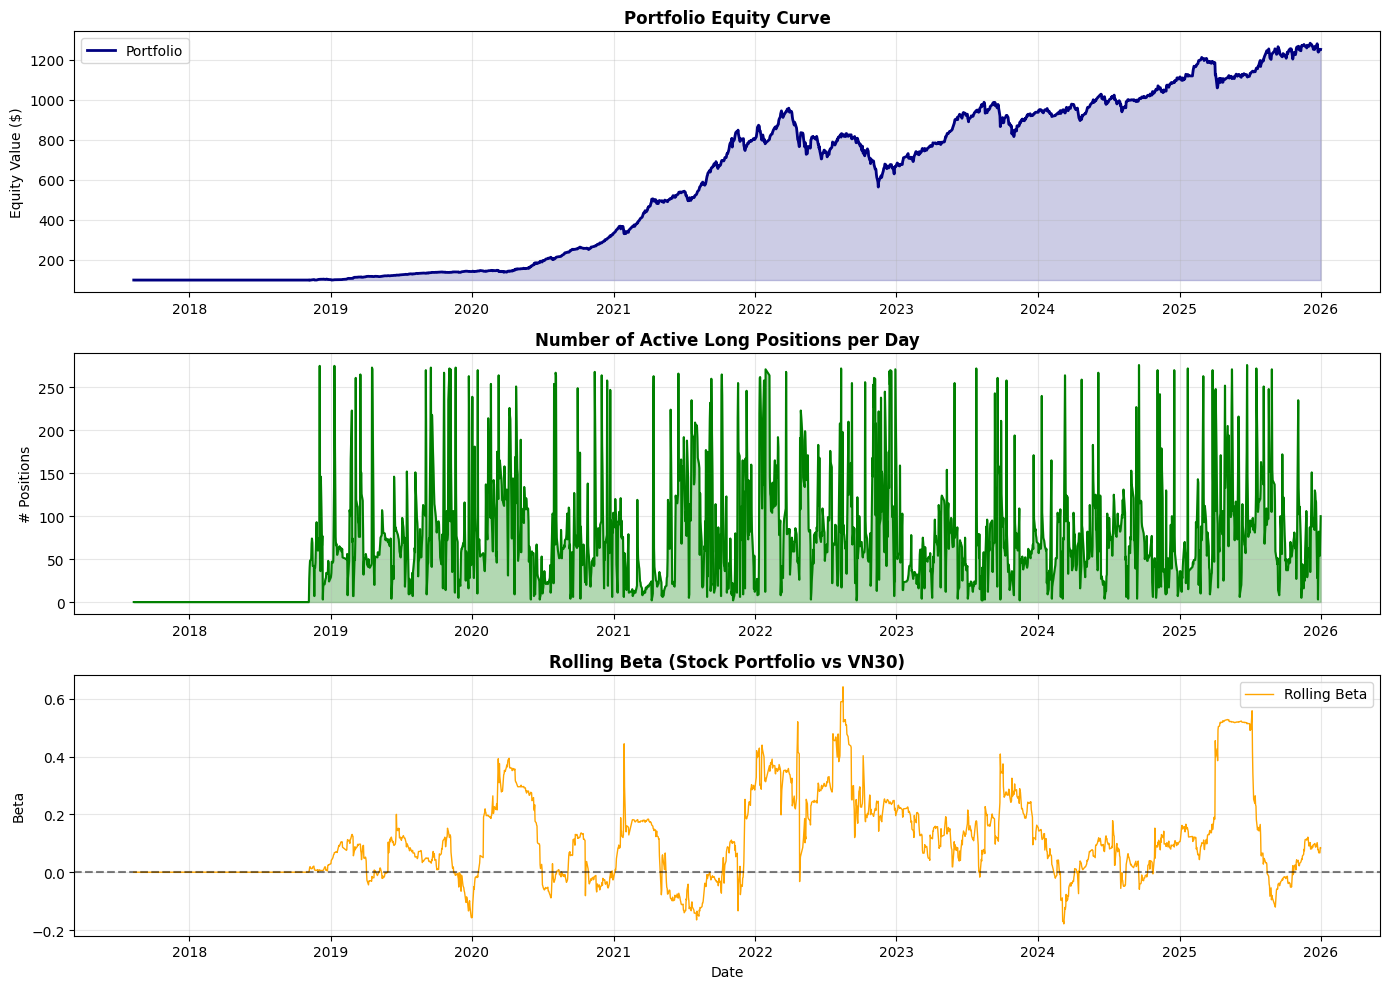

Plots complete.


In [27]:
## Plot equity curve
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Equity curve
ax = axes[0]
ax.plot(equity_curve.index, equity_curve.values, linewidth=2, color='navy', label='Portfolio')
ax.fill_between(equity_curve.index, equity_curve.iloc[0], equity_curve.values, alpha=0.2, color='navy')
ax.set_title('Portfolio Equity Curve', fontsize=12, fontweight='bold')
ax.set_ylabel('Equity Value ($)')
ax.grid(True, alpha=0.3)
ax.legend()

# Active positions over time
ax = axes[1]
ax.plot(active_positions_per_day.index, active_positions_per_day.values, linewidth=1.5, color='green')
ax.fill_between(active_positions_per_day.index, 0, active_positions_per_day.values, alpha=0.3, color='green')
ax.set_title('Number of Active Long Positions per Day', fontsize=12, fontweight='bold')
ax.set_ylabel('# Positions')
ax.grid(True, alpha=0.3)

# Rolling beta
ax = axes[2]
ax.plot(beta_series.index, beta_series.values, linewidth=1, color='orange', label='Rolling Beta')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.set_title('Rolling Beta (Stock Portfolio vs VN30)', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Beta')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print('Plots complete.')

## Summary: Baseline Pipeline Validation

This notebook implements a complete baseline Vietnam statistical arbitrage strategy:

✅ **Completed Steps:**
1. Data loading: Vietnam stocks + VN30 futures, clean & aligned
2. Universe: Simple liquidity-based selection
3. PCA: Rolling factor extraction without look-ahead bias
4. Residuals: Factor-adjusted returns
5. OU fitting: Mean-reversion speed estimation
6. S-score: Standardized mean-reversion signal
7. Signals: Long-only trading rules (no shorts)
8. Portfolio: Equal-weight construction (no optimization)
9. Hedge: Rolling beta-based VN30 futures short position
10. Backtest: Single clean function, transaction costs included
11. Outputs: Equity curve, Sharpe ratio, diagnostics

**Next Steps for Optimization:**
- Adjust PCA parameters (window, number of factors)
- Tune signal thresholds (s_open, s_close)
- Explore kappa filteri (limit=True with kappa_min)
- Add position sizing optimization
- Improve hedge efficiency
- Reduce transaction costs
- Walk-forward backtesting

**Current Status:** ✓ Conceptually correct, runnable, minimal optimization
**Validation Goal:** Ensure pipeline produces sensible results before parameter tuning